# GradCAM for HTR ViT Models

Gradient-weighted Class Activation Mapping for HTR transformer models.

**Methods implemented:**
1. GradCAM on CNN Stem (2D spatial heatmaps)
2. Gradient-Weighted Attention (attention × |gradient|)
3. Per-character GradCAM localization
4. GradCAM vs Raw Attention comparison

**Key insight:** Unlike raw attention, GradCAM highlights only *task-relevant*
regions by backpropagating from the CTC output, producing sharper character-aligned maps.

**References:**
- Selvaraju et al., Grad-CAM (ICCV 2017)
- [Attention Transfer (Zagoruyko)](https://github.com/szagoruyko/attention-transfer)
- [Probing ViTs (Sayak Paul)](https://github.com/sayakpaul/probing-vits)

In [1]:
import sys, os, json, math
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.ndimage import gaussian_filter, gaussian_filter1d

ROOT = Path(os.getcwd()).parent if 'notebook' in os.getcwd() else Path(os.getcwd())
sys.path.insert(0, str(ROOT))

from models import HTRNet
from utils.preprocessing import load_image, preprocess

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## 1. Configuration

In [5]:
EXPERIMENTS_DIR = ROOT / 'saved_models' / 'experiments'
SAMPLE_DIR = ROOT / 'notebook' / 'sample_images'
CLASSES_PATH = EXPERIMENTS_DIR / 'classes.npy'
OUTPUT_DIR = ROOT / 'outputs' / 'gradcam'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_H, IMAGE_W = 128, 1024

# ---- Select run (must be vit_rgts with CNN stem for full GradCAM) ----
RUN_ID = 'run_90'   # Best vit_rgts (test CER ~6.3%)

# ---- Select sample image ----
IMAGE_NAME = 'a01-096u-10.png'

print(f'Run: {RUN_ID}, Image: {IMAGE_NAME}')

Run: run_90, Image: a01-096u-10.png


## 2. Load Model & Image

In [6]:
def load_model(run_id, device='cpu'):
    run_dir = EXPERIMENTS_DIR / run_id
    with open(run_dir / 'config.json') as f:
        cfg = json.load(f)
    arch_ns = SimpleNamespace(**cfg['arch'])
    charset = list(np.load(str(CLASSES_PATH), allow_pickle=True))
    model = HTRNet(arch_ns, len(charset) + 1)
    state = torch.load(str(run_dir / 'model.pt'), map_location=device, weights_only=False)
    model.load_state_dict(state, strict=False)
    model.to(device).eval()
    return model, charset, cfg['arch']


def prepare_image(image_path, device='cpu'):
    img_np = load_image(str(image_path))
    img_proc = preprocess(img_np, (IMAGE_H, IMAGE_W))
    tensor = torch.from_numpy(img_proc).unsqueeze(0).unsqueeze(0).float().to(device)
    return tensor, img_proc


def ctc_greedy_decode(logits, charset):
    probs = torch.softmax(logits, dim=-1)[:, 0, :]
    indices = probs.argmax(dim=-1).cpu().numpy()
    chars, positions = [], []
    prev = 0
    for t, idx in enumerate(indices):
        if idx != 0 and idx != prev:
            chars.append(charset[idx - 1])
            positions.append(t)
        prev = idx
    return ''.join(chars), positions


model, charset, arch_cfg = load_model(RUN_ID, device)
num_registers = arch_cfg.get('num_registers', 0)
arch_type = arch_cfg['type']
has_cnn_stem = arch_cfg.get('use_cnn_stem', False)

img_tensor, img_proc = prepare_image(SAMPLE_DIR / IMAGE_NAME, device)

print(f'Arch: {arch_type}, CNN stem: {has_cnn_stem}, Registers: {num_registers}')

/home/hpc/iwi5/iwi5369h/HTR-Pipeline/.venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Arch: vit_rgts, CNN stem: True, Registers: 12


## 3. GradCAM on CNN Stem

Hooks the last CNN stem layer to capture 2D spatial feature maps.
Backpropagates from CTC logit at a target timestep → GradCAM heatmap.

In [7]:
def gradcam_cnn_stem(model, tensor, target_timestep, device):
    """
    GradCAM on CNN stem's last conv layer.

    Returns:
        cam: 2D heatmap [H', W'] where H'≈4, W'≈128
    """
    model.eval()
    x = tensor.to(device)

    # Forward through CNN stem
    stem_out = model.backbone.cnn_stem(x)          # [B, D, H', W']
    stem_features = stem_out.detach().clone()
    stem_features.requires_grad_(True)

    # Continue forward from stem features
    pooled = model.backbone.stem_pool(stem_features)
    B, D, Hp, Wp = pooled.shape
    patch_tokens = pooled.squeeze(2).transpose(1, 2)

    R = model.backbone.num_registers
    reg_tokens = model.backbone.register_tokens.expand(B, -1, -1)
    tokens = torch.cat([reg_tokens, patch_tokens], dim=1)
    S = tokens.size(1)
    pos = model.backbone.pos_embed[:, :S, :]
    tokens = tokens + pos

    encoded = model.backbone.encoder(tokens)
    patch_out = encoded[:, R:, :]
    seq_tokens = patch_out.transpose(0, 1)
    seq_4d = seq_tokens.permute(1, 2, 0).unsqueeze(2)

    model.top.eval()
    logits = model.top(seq_4d)  # [T, B, C]

    # Target: max logit at target timestep
    t = min(target_timestep, logits.shape[0] - 1)
    target_logit = logits[t, 0, :].max()
    target_logit.backward()

    grad = stem_features.grad  # [B, D, H', W']
    if grad is None:
        return np.zeros((4, 128))

    # GradCAM: global-average-pool gradients → channel weights → weighted sum
    weights = grad.mean(dim=(2, 3), keepdim=True)  # [B, D, 1, 1]
    cam = (weights * stem_features.detach()).sum(dim=1, keepdim=True)  # [B, 1, H', W']
    cam = F.relu(cam).squeeze().cpu().numpy()

    cam_min, cam_max = cam.min(), cam.max()
    if cam_max > cam_min:
        cam = (cam - cam_min) / (cam_max - cam_min)

    return cam


if not has_cnn_stem:
    print('⚠ Selected model does not use CNN stem. Stem GradCAM not available.')
    print('Use a vit_rgts run with use_cnn_stem=true (runs 60-71, 76-92).')
else:
    # Get decoded text and character positions
    with torch.no_grad():
        logits = model(img_tensor)
    text, char_pos = ctc_greedy_decode(logits, charset)
    print(f'Decoded: \"{text}\"')
    print(f'Character positions (timesteps): {char_pos[:10]}...')

Decoded: " people. "
Character positions (timesteps): [0, 2, 5, 7, 11, 14, 15, 21, 126]...


## 4. Per-Character GradCAM

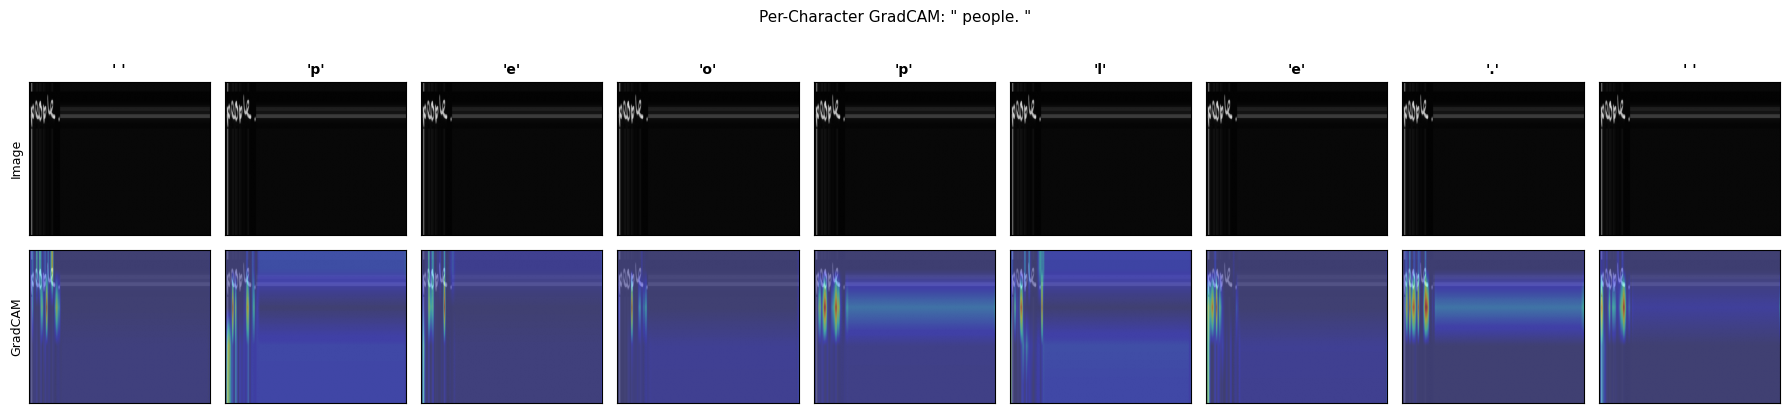

In [8]:
if has_cnn_stem and len(char_pos) > 0:
    n_chars = min(10, len(char_pos))
    cams = []
    for ci in range(n_chars):
        cam = gradcam_cnn_stem(model, img_tensor, char_pos[ci], device)
        cams.append(cam)

    fig, axes = plt.subplots(2, n_chars, figsize=(2 * n_chars, 4))

    for ci in range(n_chars):
        # Original image
        axes[0, ci].imshow(img_proc, cmap='gray', aspect='auto')
        axes[0, ci].set_title(f'\'{text[ci]}\'', fontsize=10, fontweight='bold')
        axes[0, ci].set_xticks([]); axes[0, ci].set_yticks([])

        # GradCAM overlay
        cam_resized = np.array(
            F.interpolate(
                torch.from_numpy(cams[ci]).unsqueeze(0).unsqueeze(0).float(),
                size=(IMAGE_H, IMAGE_W), mode='bilinear', align_corners=False
            ).squeeze().numpy()
        )
        axes[1, ci].imshow(img_proc, cmap='gray', aspect='auto', alpha=0.6)
        axes[1, ci].imshow(cam_resized, cmap='jet', aspect='auto', alpha=0.4)
        axes[1, ci].set_xticks([]); axes[1, ci].set_yticks([])

    axes[0, 0].set_ylabel('Image', fontsize=9)
    axes[1, 0].set_ylabel('GradCAM', fontsize=9)
    plt.suptitle(f'Per-Character GradCAM: \"{text[:n_chars]}\"', fontsize=11, y=1.02)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'{RUN_ID}_per_char_gradcam.png', dpi=200, bbox_inches='tight')
    plt.show()

## 5. Gradient-Weighted Attention

Multiply raw attention by the gradient magnitude to retain only task-relevant
attention patterns. This is analogous to GradCAM but applied to attention weights
instead of convolutional feature maps.

In [ ]:
def gradient_weighted_attention(model, tensor, charset, device, n_chars=5):
    """
    Attention × |∂logit/∂attention| from the last transformer layer.

    Returns:
        per_char_attn: list of 1D arrays [T] per character
        text: decoded string
        char_pos: list of peak timesteps
    """
    model.eval()
    x = tensor.to(device)
    B, C, H, W = x.shape

    # Forward through CNN stem
    stem_out = model.backbone.cnn_stem(x)
    pooled = model.backbone.stem_pool(stem_out)
    B, D, Hp, Wp = pooled.shape
    patch_tokens = pooled.squeeze(2).transpose(1, 2)

    R = model.backbone.num_registers
    reg_tokens = model.backbone.register_tokens.expand(B, -1, -1)
    tokens = torch.cat([reg_tokens, patch_tokens], dim=1)
    S = tokens.size(1)
    pos = model.backbone.pos_embed[:, :S, :]
    tokens = tokens + pos
    tokens = model.backbone.emb_dropout(tokens)

    # Forward all layers except last
    x_tokens = tokens
    for layer in model.backbone.encoder.layers[:-1]:
        x_tokens = layer(x_tokens)

    # Last layer: manually compute attention with gradients
    last_layer = model.backbone.encoder.layers[-1]
    attn_module = last_layer.self_attn
    embed_dim = attn_module.embed_dim
    num_heads = attn_module.num_heads
    head_dim = embed_dim // num_heads

    normed = last_layer.norm1(x_tokens)
    q, k, v = F.linear(
        normed, attn_module.in_proj_weight, attn_module.in_proj_bias
    ).chunk(3, dim=-1)

    q = q.view(B, S, num_heads, head_dim).transpose(1, 2)
    k = k.view(B, S, num_heads, head_dim).transpose(1, 2)
    v = v.view(B, S, num_heads, head_dim).transpose(1, 2)

    attn_weights = torch.matmul(q, k.transpose(-1, -2)) / math.sqrt(head_dim)
    attn_weights = torch.softmax(attn_weights, dim=-1)  # [B, H, S, S]

    # Make attention weights leaf for gradient computation
    attn_leaf = attn_weights.detach().clone().requires_grad_(True)

    # Continue forward with this attention
    attn_out = torch.matmul(attn_leaf, v)
    attn_out = attn_out.transpose(1, 2).contiguous().view(B, S, embed_dim)
    attn_out = F.linear(attn_out, attn_module.out_proj.weight, attn_module.out_proj.bias)

    x_tokens_out = x_tokens + attn_out
    ff_normed = last_layer.norm2(x_tokens_out)
    ff_out = last_layer.linear2(F.gelu(last_layer.linear1(ff_normed)))
    x_tokens_out = x_tokens_out + ff_out

    # Through CTC head
    patch_out = x_tokens_out[:, R:, :]
    seq_tokens = patch_out.transpose(0, 1)
    seq_4d = seq_tokens.permute(1, 2, 0).unsqueeze(2)
    model.top.eval()
    logits = model.top(seq_4d)  # [T, B, C]

    # Decode
    text_decoded, char_pos_decoded = ctc_greedy_decode(logits.detach(), charset)

    # Compute gradient-weighted attention per character
    per_char_attn = []
    for ci in range(min(n_chars, len(char_pos_decoded))):
        t = char_pos_decoded[ci]
        if attn_leaf.grad is not None:
            attn_leaf.grad.zero_()

        target = logits[t, 0, :].max()
        target.backward(retain_graph=True)

        if attn_leaf.grad is not None:
            grad_attn = (attn_leaf * attn_leaf.grad.abs())[0]  # [H, S, S]
            # Average heads, get attention TO patch tokens from query at timestep t+R
            weighted = grad_attn.mean(dim=0)[R + t, R:]  # [T]
            weighted = weighted.detach().cpu().numpy()
            weighted = (weighted - weighted.min()) / (weighted.max() - weighted.min() + 1e-8)
            per_char_attn.append(weighted)
        else:
            per_char_attn.append(np.zeros(logits.shape[0]))

    return per_char_attn, text_decoded, char_pos_decoded


if has_cnn_stem:
    n_chars = min(8, len(text))
    grad_attns, text_ga, pos_ga = gradient_weighted_attention(
        model, img_tensor, charset, device, n_chars=n_chars
    )
    print(f'Decoded: \"{text_ga}\"')
    print(f'Computed gradient-weighted attention for {len(grad_attns)} characters')

## 6. Visualize Gradient-Weighted Attention

In [ ]:
if has_cnn_stem and len(grad_attns) > 0:
    n = len(grad_attns)
    fig, axes = plt.subplots(n + 1, 1, figsize=(14, 1.5 * (n + 1)))

    axes[0].imshow(img_proc, cmap='gray', aspect='auto')
    axes[0].set_title(f'Input: \"{text_ga}\"', fontsize=10)
    axes[0].set_xticks([]); axes[0].set_yticks([])

    for ci in range(n):
        ga = grad_attns[ci]
        ga_smooth = gaussian_filter1d(ga, sigma=2)
        ga_smooth = (ga_smooth - ga_smooth.min()) / (ga_smooth.max() - ga_smooth.min() + 1e-8)
        T = len(ga_smooth)
        hm = np.interp(np.linspace(0, T-1, IMAGE_W), np.arange(T), ga_smooth)
        hm_2d = np.tile(hm, (IMAGE_H, 1))

        axes[ci + 1].imshow(img_proc, cmap='gray', aspect='auto', alpha=0.5)
        axes[ci + 1].imshow(hm_2d, cmap='hot', aspect='auto', alpha=0.5)
        char_label = text_ga[ci] if ci < len(text_ga) else '?'
        axes[ci + 1].set_title(f'Char \'{char_label}\' (t={pos_ga[ci]})', fontsize=9)
        axes[ci + 1].set_xticks([]); axes[ci + 1].set_yticks([])

    plt.suptitle('Gradient-Weighted Attention per Character', fontsize=11, y=1.01)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'{RUN_ID}_grad_weighted_attn.png', dpi=200, bbox_inches='tight')
    plt.show()

## 7. GradCAM vs Raw Attention Comparison

Side-by-side comparison showing that GradCAM produces sharper, more
character-aligned maps than raw attention.

In [ ]:
if has_cnn_stem:
    # Get raw attention from last layer
    with torch.no_grad():
        results = model.forward_explain(img_tensor)
    attn_maps = results[2]
    R = num_registers

    last_attn = attn_maps[-1][0]  # [H, S, S]
    patch_attn = last_attn[:, R:, R:].mean(dim=0)  # [T, T]
    raw_importance = patch_attn.sum(dim=0).numpy()
    raw_importance = (raw_importance - raw_importance.min()) / (raw_importance.max() - raw_importance.min() + 1e-8)
    raw_importance = gaussian_filter1d(raw_importance, sigma=2)
    raw_importance = (raw_importance - raw_importance.min()) / (raw_importance.max() - raw_importance.min() + 1e-8)

    # Aggregate GradCAM across all characters
    all_cams = []
    for ci in range(min(len(char_pos), 15)):
        cam = gradcam_cnn_stem(model, img_tensor, char_pos[ci], device)
        all_cams.append(cam)
    agg_cam = np.mean(all_cams, axis=0)  # [H', W']
    agg_cam = (agg_cam - agg_cam.min()) / (agg_cam.max() - agg_cam.min() + 1e-8)

    # Resize
    cam_resized = F.interpolate(
        torch.from_numpy(agg_cam).unsqueeze(0).unsqueeze(0).float(),
        size=(IMAGE_H, IMAGE_W), mode='bilinear', align_corners=False
    ).squeeze().numpy()

    T = len(raw_importance)
    raw_resized = np.interp(np.linspace(0, T-1, IMAGE_W), np.arange(T), raw_importance)
    raw_2d = np.tile(raw_resized, (IMAGE_H, 1))

    fig, axes = plt.subplots(3, 1, figsize=(14, 5))

    axes[0].imshow(img_proc, cmap='gray', aspect='auto')
    axes[0].set_title(f'Input: \"{text}\"', fontsize=10)
    axes[0].set_xticks([]); axes[0].set_yticks([])

    axes[1].imshow(img_proc, cmap='gray', aspect='auto', alpha=0.5)
    axes[1].imshow(raw_2d, cmap='jet', aspect='auto', alpha=0.5)
    axes[1].set_title('Raw Attention (last layer, head-averaged)', fontsize=10)
    axes[1].set_xticks([]); axes[1].set_yticks([])

    axes[2].imshow(img_proc, cmap='gray', aspect='auto', alpha=0.5)
    axes[2].imshow(cam_resized, cmap='jet', aspect='auto', alpha=0.5)
    axes[2].set_title('GradCAM (aggregated over characters)', fontsize=10)
    axes[2].set_xticks([]); axes[2].set_yticks([])

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'{RUN_ID}_gradcam_vs_attention.png', dpi=200, bbox_inches='tight')
    plt.show()

## 8. Full-Sequence GradCAM Heatmap

Compute GradCAM for every decoded character and display as a single heatmap
with character labels aligned to their spatial positions.

In [ ]:
if has_cnn_stem and len(char_pos) > 0:
    # Compute GradCAM for all characters
    char_cams = []
    for ci in range(len(char_pos)):
        cam = gradcam_cnn_stem(model, img_tensor, char_pos[ci], device)
        cam_up = F.interpolate(
            torch.from_numpy(cam).unsqueeze(0).unsqueeze(0).float(),
            size=(IMAGE_H, IMAGE_W), mode='bilinear', align_corners=False
        ).squeeze().numpy()
        char_cams.append(cam_up)

    # Composite: max over all character heatmaps
    composite = np.max(char_cams, axis=0)
    composite = (composite - composite.min()) / (composite.max() - composite.min() + 1e-8)

    fig, axes = plt.subplots(2, 1, figsize=(14, 4))

    axes[0].imshow(img_proc, cmap='gray', aspect='auto')
    axes[0].set_title(f'Input: \"{text}\"', fontsize=10)
    axes[0].set_xticks([]); axes[0].set_yticks([])

    axes[1].imshow(img_proc, cmap='gray', aspect='auto', alpha=0.4)
    im = axes[1].imshow(composite, cmap='jet', aspect='auto', alpha=0.6)
    axes[1].set_title('Full-Sequence GradCAM (all characters)', fontsize=10)
    axes[1].set_xticks([]); axes[1].set_yticks([])

    # Mark character positions
    T_total = len(raw_importance) if 'raw_importance' in dir() else 128
    for ci in range(len(char_pos)):
        x_px = int(char_pos[ci] / T_total * IMAGE_W)
        if ci < len(text):
            axes[1].text(x_px, IMAGE_H - 5, text[ci], color='white',
                        fontsize=6, ha='center', va='bottom', fontweight='bold',
                        bbox=dict(boxstyle='round,pad=0.1', facecolor='black', alpha=0.5))

    plt.colorbar(im, ax=axes[1], fraction=0.01, pad=0.01)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'{RUN_ID}_full_seq_gradcam.png', dpi=200, bbox_inches='tight')
    plt.show()

## 9. Multi-Image GradCAM Gallery

In [ ]:
if has_cnn_stem:
    sample_images = sorted(SAMPLE_DIR.glob('*.png'))[:6]
    gt_lines = {}
    gt_path = SAMPLE_DIR / 'gt.txt'
    if gt_path.exists():
        for line in gt_path.read_text().strip().split('\n'):
            parts = line.split(' ', 1)
            if len(parts) == 2:
                gt_lines[parts[0]] = parts[1]

    fig, axes = plt.subplots(len(sample_images), 2, figsize=(14, 2 * len(sample_images)))

    for i, img_path in enumerate(sample_images):
        tensor_i, proc_i = prepare_image(img_path, device)

        with torch.no_grad():
            logits_i = model(tensor_i)
        text_i, pos_i = ctc_greedy_decode(logits_i, charset)

        # Aggregate GradCAM
        cams_i = []
        for ci in range(min(len(pos_i), 15)):
            cam = gradcam_cnn_stem(model, tensor_i, pos_i[ci], device)
            cams_i.append(cam)

        if len(cams_i) > 0:
            agg = np.max(cams_i, axis=0)
            agg = (agg - agg.min()) / (agg.max() - agg.min() + 1e-8)
            agg_up = F.interpolate(
                torch.from_numpy(agg).unsqueeze(0).unsqueeze(0).float(),
                size=(IMAGE_H, IMAGE_W), mode='bilinear', align_corners=False
            ).squeeze().numpy()
        else:
            agg_up = np.zeros((IMAGE_H, IMAGE_W))

        gt = gt_lines.get(img_path.stem, '')

        axes[i, 0].imshow(proc_i, cmap='gray', aspect='auto')
        axes[i, 0].set_title(f'GT: \"{gt}\"', fontsize=8)
        axes[i, 0].set_xticks([]); axes[i, 0].set_yticks([])

        axes[i, 1].imshow(proc_i, cmap='gray', aspect='auto', alpha=0.4)
        axes[i, 1].imshow(agg_up, cmap='jet', aspect='auto', alpha=0.6)
        axes[i, 1].set_title(f'Pred: \"{text_i}\"', fontsize=8)
        axes[i, 1].set_xticks([]); axes[i, 1].set_yticks([])

    plt.suptitle('GradCAM — Multi-Image Gallery', fontsize=11, y=1.01)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'{RUN_ID}_multi_image_gradcam.png', dpi=200, bbox_inches='tight')
    plt.show()

## 10. Register Effect on GradCAM (Ablation)

Compare GradCAM across different register configurations to show
how registers affect the model's spatial focus.

In [ ]:
# Register sweep runs (modify as needed based on your experiments)
REGISTER_RUNS = {
    0: 'run_76',   # 0 registers
    4: 'run_84',   # 4 registers
    8: 'run_63',   # 8 registers
    16: 'run_71',  # 16 registers
}

image_path = SAMPLE_DIR / IMAGE_NAME

fig, axes = plt.subplots(len(REGISTER_RUNS) + 1, 1,
                          figsize=(14, 2 * (len(REGISTER_RUNS) + 1)))

_, proc_img = prepare_image(image_path, device)
axes[0].imshow(proc_img, cmap='gray', aspect='auto')
axes[0].set_title(f'Input: {IMAGE_NAME}', fontsize=10)
axes[0].set_xticks([]); axes[0].set_yticks([])

for idx, (n_reg, run_id) in enumerate(REGISTER_RUNS.items()):
    try:
        model_r, charset_r, cfg_r = load_model(run_id, device)
        tensor_r, _ = prepare_image(image_path, device)

        with torch.no_grad():
            logits_r = model_r(tensor_r)
        text_r, pos_r = ctc_greedy_decode(logits_r, charset_r)

        # Aggregate GradCAM
        cams_r = []
        for ci in range(min(len(pos_r), 10)):
            cam = gradcam_cnn_stem(model_r, tensor_r, pos_r[ci], device)
            cams_r.append(cam)

        if cams_r:
            agg = np.max(cams_r, axis=0)
            agg = (agg - agg.min()) / (agg.max() - agg.min() + 1e-8)
            agg_up = F.interpolate(
                torch.from_numpy(agg).unsqueeze(0).unsqueeze(0).float(),
                size=(IMAGE_H, IMAGE_W), mode='bilinear', align_corners=False
            ).squeeze().numpy()
        else:
            agg_up = np.zeros((IMAGE_H, IMAGE_W))

        ax = axes[idx + 1]
        ax.imshow(proc_img, cmap='gray', aspect='auto', alpha=0.4)
        ax.imshow(agg_up, cmap='jet', aspect='auto', alpha=0.6)
        ax.set_title(f'R={n_reg} ({run_id}): \"{text_r}\"', fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])

        del model_r
        torch.cuda.empty_cache() if torch.cuda.is_available() else None
    except Exception as e:
        axes[idx + 1].text(0.5, 0.5, f'{run_id}: {e}', transform=axes[idx + 1].transAxes,
                            ha='center', fontsize=8)
        axes[idx + 1].set_xticks([]); axes[idx + 1].set_yticks([])

plt.suptitle('Register Effect on GradCAM', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f'register_ablation_gradcam.png', dpi=200, bbox_inches='tight')
plt.show()